# Land cover (ESRI LULC) & forest loss (Hansen)

Two categorical COG products read with `rioxarray` from the **bundled demo pack**
(`hackathon_demo_data/`, the **D_Chablis_Vineyard** AOI) — local files, no S3, no credentials.

- **ESRI LULC**: `esri_lulc/2025/lulc_D_Chablis_Vineyard_2025.tif` - uint8 class codes, 10 m, EPSG:4326, `0` = nodata. Palette in `esri_lulc_classes.json`.
- **Hansen lossyear**: `hansen_lossyear/hansen_lossyear.tif` - uint8, `0` = no loss, `1`-`24` -> loss year `2000 + n`, ~30 m, EPSG:4326.

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import rioxarray  # noqa: F401  (registers the .rio accessor)
from matplotlib.patches import Patch

# Local demo pack - no S3, no credentials. See the repo README to download/unzip it.
DATA_DIR = Path("hackathon_demo_data")

## ESRI land cover

codes present: [ 0  1  2  5  7 11]


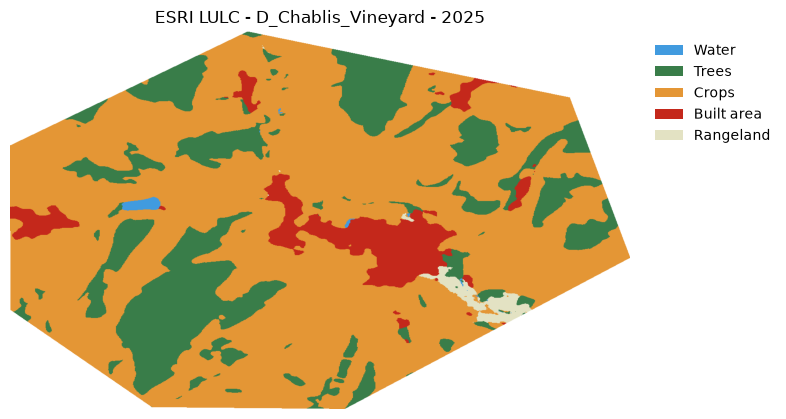

In [2]:
AOI = "D_Chablis_Vineyard"   # Chablis vineyards, Burgundy - crop/forest/built mix
YEAR = 2025

# class code -> (name, hex colour), shared across all years
classes = json.loads((DATA_DIR / "esri_lulc_classes.json").read_text())["classes"]

uri = DATA_DIR / "esri_lulc" / str(YEAR) / f"lulc_{AOI}_{YEAR}.tif"
lulc = rioxarray.open_rasterio(uri).squeeze("band", drop=True)
codes = lulc.values
print("codes present:", np.unique(codes))

# build an RGB image straight from the palette (codes are non-contiguous)
def hex2rgb(h):
    return np.array([int(h[i:i + 2], 16) for i in (1, 3, 5)], "float32") / 255

rgb = np.ones((*codes.shape, 3), "float32")   # nodata (0) stays white
present = [c for c in np.unique(codes) if str(c) in classes]
for c in present:
    rgb[codes == c] = hex2rgb(classes[str(c)]["hex"])

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(rgb)
ax.set_title(f"ESRI LULC - {AOI} - {YEAR}")
ax.axis("off")
handles = [Patch(facecolor=classes[str(c)]["hex"], label=classes[str(c)]["name"]) for c in present]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.savefig("02_lulc.png", dpi=120, bbox_inches="tight")

## Hansen forest-loss year

The demo pack only bundles the **D_Chablis_Vineyard** AOI, a vineyard/cropland region — so
expect **little forest loss** here (mostly the `0` = no-loss class). On a forested hackathon
AOI (e.g. a tropical site) the same code lights up with stand-replacement clearing and a clear
loss-year pattern.

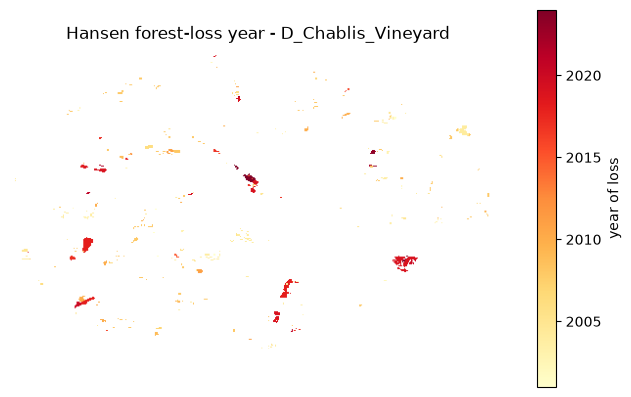

In [3]:
HANSEN_AOI = "D_Chablis_Vineyard"
uri = DATA_DIR / "hansen_lossyear" / "hansen_lossyear.tif"
loss = rioxarray.open_rasterio(uri, masked=False).squeeze("band", drop=True)

year = loss.where(loss > 0) + 2000          # codes -> calendar year, no-loss -> NaN

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(year, cmap="YlOrRd", vmin=2001, vmax=2024)
ax.set_title(f"Hansen forest-loss year - {HANSEN_AOI}")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.7, label="year of loss")
fig.savefig("02_hansen_map.png", dpi=120, bbox_inches="tight")

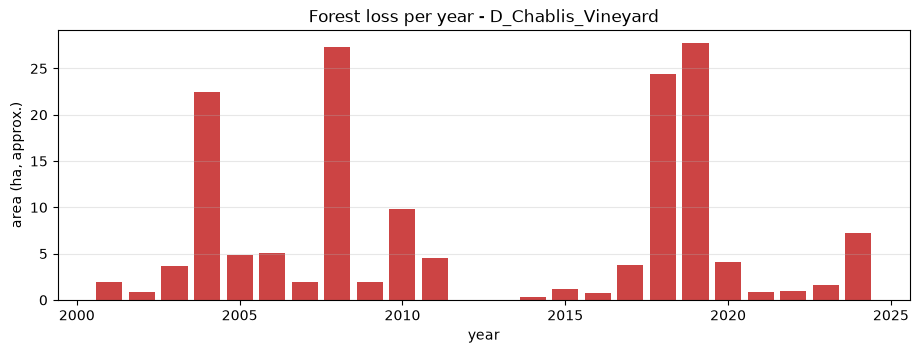

In [4]:
# loss pixels per year + rough area (each pixel ~30 m x 30 m = 0.09 ha)
vals = loss.values
codes, counts = np.unique(vals[vals > 0], return_counts=True)
years = codes.astype(int) + 2000
ha = counts * (30 * 30) / 10_000

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(years, ha, color="#c44")
ax.set_title(f"Forest loss per year - {HANSEN_AOI}")
ax.set_ylabel("area (ha, approx.)")
ax.set_xlabel("year")
ax.grid(axis="y", alpha=0.3)
fig.savefig("02_hansen_bars.png", dpi=120, bbox_inches="tight")